In [105]:
import pandas as pd
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [106]:
import os
# arquivo salvo anteriormente na base das redes neurais artificiais
DRIVE_DIRECTORY = '../10-Redes_neurais_artificiais/exercicios/novo/'

##  22.8) Exercício => K-means


### Base de dados cobertura vegetal


Neste exercício será usado a base de dados de cobertura vegetal, explorada nos exercícios da **Parte 1 - Classificação** das redes neurais.

Comece carregando os dados do arquivo `cov_types.csv` armazenado na pasta do Drive.

no github: Machine_Learning/Machine_Learning_AZ/8-Redes_neurais_artificiais|/novo_exercicios/

In [107]:
base = pd.read_csv(os.path.join(DRIVE_DIRECTORY, 'cov_types.csv'))
base.tail(7)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
9993,2942.0,351.0,10.0,391.0,29.0,5337.0,203.0,224.0,159.0,2105.0,0,28,Lodgepole Pine
9994,2055.0,327.0,19.0,30.0,14.0,532.0,169.0,215.0,183.0,684.0,3,13,Douglas-fir
9995,2917.0,90.0,9.0,247.0,25.0,4095.0,235.0,225.0,121.0,3901.0,0,28,Lodgepole Pine
9996,3015.0,38.0,8.0,361.0,74.0,4846.0,220.0,223.0,138.0,1611.0,0,28,Lodgepole Pine
9997,3052.0,79.0,19.0,90.0,11.0,1003.0,241.0,203.0,85.0,1490.0,2,22,Spruce/Fir
9998,2958.0,58.0,6.0,319.0,19.0,2468.0,225.0,227.0,137.0,2280.0,0,28,Lodgepole Pine
9999,2682.0,91.0,13.0,162.0,32.0,1369.0,240.0,219.0,108.0,1661.0,2,10,Lodgepole Pine


### atributos relacionados as plantas

Exiba os dados para uma inspeção inicial.

Desta vez, nós vamos remover os atributos categóricos, `Wilderness_Area` e `Soil_Type`, pois para apresentá-los ao algoritmo, nós precisaríamos usar One Hot Encoding, o que adiciona muitas colunas no dataset, e como nossos dados são limitados a 10 mil exemplos, isso pode prejudicar o algoritmo K-Means.

Atributos categóricos são variáveis que representam categorias ou grupos, e não valores numéricos ou quantidades.

Pense neles como características que classificam um dado em um conjunto limitado de opções. Eles são o oposto de atributos numéricos, que são representados por números e podem ser medidos (como idade, salário ou altura).

Exemplos Comuns
Gênero: Masculino, Feminino.

Cor dos olhos: Azul, Castanho, Verde.

Estado civil: Solteiro, Casado, Divorciado.

País de origem: Brasil, Canadá, Japão.

Nível de escolaridade: Ensino Fundamental, Ensino Médio, Ensino Superior. (Este é um exemplo de categoria com uma ordem clara).

In [108]:
print('Wilderness_Area')
print(sorted(list(base["Wilderness_Area"].unique())))
print('Soil_Type')
print(sorted(list(base["Soil_Type"].unique())))


Wilderness_Area
[0, 1, 2, 3]
Soil_Type
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [109]:

# será removido

base = base.drop(["Wilderness_Area", "Soil_Type"], axis=1)
base.head(5)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type
0,2767.0,66.0,17.0,210.0,18.0,1190.0,234.0,204.0,96.0,2251.0,Lodgepole Pine
1,2724.0,160.0,19.0,60.0,4.0,1350.0,236.0,240.0,127.0,2514.0,Lodgepole Pine
2,2360.0,65.0,7.0,127.0,21.0,1377.0,227.0,226.0,134.0,339.0,Ponderosa Pine
3,2995.0,45.0,4.0,285.0,30.0,5125.0,221.0,231.0,146.0,5706.0,Lodgepole Pine
4,2400.0,106.0,27.0,150.0,63.0,342.0,253.0,196.0,51.0,811.0,Ponderosa Pine


# Separe a coluna `Cover_Type` em uma variável `y` (já que esta é a classe do dataset), e utilize o método `value_counts` para relembrar quantas classes esse problema contém, e qual sua frequência.

In [110]:
y = base["Cover_Type"]  # rótulo original
y.value_counts()

Cover_Type
Lodgepole Pine       4847
Spruce/Fir           3714
Ponderosa Pine        581
Krummholz             362
Douglas-fir           278
Aspen                 163
Cottonwood/Willow      55
Name: count, dtype: int64

Agora separe o restante das colunas em uma variável `X`, e já recupere o atributo `values` para ter um NumPy array. Exiba este array.

In [111]:
base.iloc[:, :-1].columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points'],
      dtype='object')

In [112]:
len(base.iloc[:, :-1].columns)

10

In [113]:
X = base.iloc[:, :-1].values
X

array([[2767.,   66.,   17., ...,  204.,   96., 2251.],
       [2724.,  160.,   19., ...,  240.,  127., 2514.],
       [2360.,   65.,    7., ...,  226.,  134.,  339.],
       ...,
       [3052.,   79.,   19., ...,  203.,   85., 1490.],
       [2958.,   58.,    6., ...,  227.,  137., 2280.],
       [2682.,   91.,   13., ...,  219.,  108., 1661.]])

#### Como os dados estão em escalas diferentes, instancie um escalonador do tipo `StandardScaler` e escalone `X` com ele.

#### para padronizar ou escalonar os dados, normalização usando a média e o desvio padrão

In [114]:
# deixar os dados tudo no mesmo padrão
scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[-0.71700375, -0.78934465,  0.38187624, ..., -0.96994893,
        -1.19597298,  0.19948581],
       [-0.87120088,  0.05516249,  0.6497092 , ...,  0.84361411,
        -0.38987904,  0.39804796],
       [-2.17649753, -0.79832877, -0.95728858, ...,  0.1383396 ,
        -0.20785782, -1.2440535 ],
       ...,
       [ 0.30500049, -0.67255111,  0.6497092 , ..., -1.02032568,
        -1.48200632, -0.37506096],
       [-0.03208161, -0.8612176 , -1.09120506, ...,  0.18871635,
        -0.12984873,  0.22138049],
       [-1.02181203, -0.56474169, -0.15378969, ..., -0.21429766,
        -0.88393662, -0.24595781]])

In [115]:
scaler.get_params()

{'copy': True, 'with_mean': True, 'with_std': True}

#### Agora instancie e ajuste um algoritmo do tipo `KMeans`. Utilize `n_clusters` igual ao número de classes do dataset.

In [116]:
import math
print(len(base.iloc[:, :-1].columns))
# Use a função sqrt() da biblioteca math
resultado_num_cluster = math.sqrt(len(base.iloc[:, :-1].columns)/2)
print(resultado_num_cluster) # ideal a quantidade de cluster

10
2.23606797749979


In [117]:
# utilizar 7 cluster

In [118]:
km = KMeans(n_clusters=7)
km.fit(X)

KMeans(n_clusters=7)

In [119]:
km.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 7,
 'n_init': 'auto',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

### Recupere e exiba os centroides.

In [120]:
centroids = km.cluster_centers_
centroids # dados escalonados

array([[ 0.37151224,  1.14823869, -0.29142083, -0.13731779, -0.27304327,
         0.12551443, -0.58200147,  0.69594178,  0.90315741, -0.30034968],
       [-0.29638   , -0.64869461, -0.36653759, -0.32522762, -0.42824874,
        -0.62769829,  0.55072083,  0.04763309, -0.36369826, -0.21396897],
       [-0.51720783, -0.76904327,  1.34413278, -0.16468552,  0.24535341,
        -0.50521199,  0.57794063, -1.65572688, -1.58827671, -0.33989667],
       [ 0.74438479, -0.01869457, -0.02899445,  1.85534582,  1.89282891,
        -0.10979514,  0.01591413,  0.21642616,  0.11383911, -0.04245979],
       [-1.01038147,  1.33324381,  1.40266195, -0.23328241,  0.36717982,
        -0.54186367, -2.09643633, -0.31105117,  1.32970227, -0.50907718],
       [-0.09901304, -0.17845554, -0.59259295,  0.06454506, -0.25186715,
         0.89230545,  0.23882474,  0.25083418,  0.0282891 ,  2.3424372 ],
       [ 0.53873374, -0.60493221, -0.49455369, -0.23815786, -0.38834721,
         1.13572827,  0.52394559,  0.13888019

voltar aos valores padrões, de acordo com as bases iniciais dos dados

Aplique o método `inverse_transform` do escalonador para visualizar os centroides na escala original.

In [121]:
scaler.inverse_transform(centroids)

array([[3070.54771979,  281.66760696,   11.9722614 ,  241.70568876,
          30.72308416, 2553.34649741,  197.01504466,  237.06864128,
         176.72637518, 1588.95674659],
       [2884.29674306,   81.65540812,   11.41133896,  201.96823482,
          21.69240048, 1375.35705669,  227.19219944,  224.19943707,
         128.00683554, 1703.3699236 ],
       [2822.7158516 ,   68.25969646,   24.18549747,  235.91821248,
          60.88617201, 1566.91989882,  227.91736931,  190.38701518,
          80.91315346, 1536.57588533],
       [3174.52837977,  151.77915377,   13.93188854,  663.09597523,
         156.74509804, 2185.33333333,  212.94427245,  227.5500516 ,
         146.37151703, 1930.5376677 ],
       [2685.18757192,  302.26006904,   24.62255466,  221.41196778,
          67.97468354, 1509.59838895,  156.66858458,  217.07940161,
         193.13003452, 1312.49252014],
       [2939.33524684,  133.99655568,    9.72330654,  284.39380023,
          31.95522388, 3752.5717566 ,  218.88289323,  228

Recupere e exiba os rótulos atribuídos pelo algoritmo KMeans em uma variável `labels`.

### verifica o rótulo ou número que cada dado pertence, em qual cluster pertence

Recupere e exiba os rótulos atribuídos pelo algoritmo KMeans em uma variável `labels`.

In [122]:
labels = km.labels_
labels

array([2, 1, 1, ..., 2, 1, 1], dtype=int32)

In [123]:
set(labels)

{0, 1, 2, 3, 4, 5, 6}

# vamos avaliar a quantidade de cluster

#### O WCSS (Within-Cluster Sum of Squares) é a métrica usada no K-Means para medir a variação interna dos clusters.

### Agora aplique o método do cotovelo para verificar se o número de clusters igual a 7 é o melhor valor para agrupar este dataset. Faça uma pesquisa com 1 até 10 clusters, e plote o gráfico correspondente.

In [124]:
# valor do cluster ideal é quando não há mais uma queda significativa

In [125]:
# utilizar 6, 7 ou 8 como cálculo fixo de cluster seria ideal, ver figura abaixo e salva

In [126]:
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=0)
    km.fit(X)
    wcss.append(km.inertia_)
    print(i,km.inertia_)


1 100000.00000000004
2 79588.34267374486
3 69864.3164208976
4 63194.27620421423
5 58065.95129942955
6 52983.389171485134
7 50659.4661139256
8 47874.01356626696
9 46000.1069691932
10 44709.78867744916


In [127]:
wcss

[100000.00000000004,
 79588.34267374486,
 69864.3164208976,
 63194.27620421423,
 58065.95129942955,
 52983.389171485134,
 50659.4661139256,
 47874.01356626696,
 46000.1069691932,
 44709.78867744916]

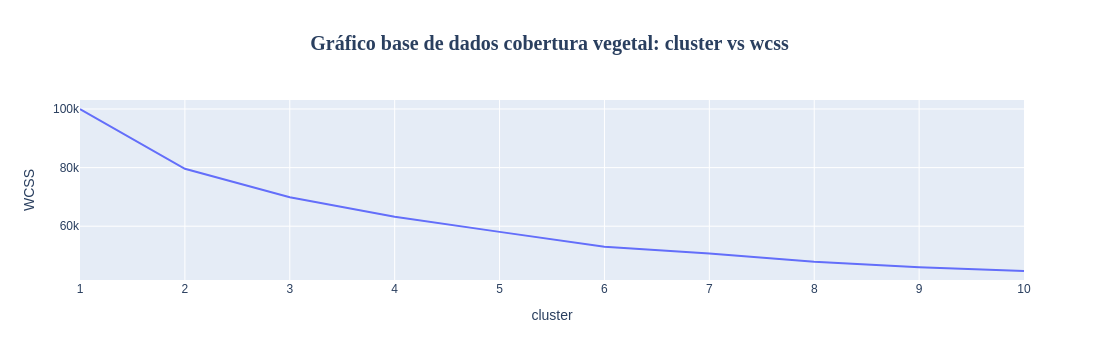

In [128]:
fig = px.line(x=range(1, 11), y=wcss, title='<b>Gráfico base de dados cobertura vegetal: cluster vs wcss </b>')

# Atualiza o layout para renomear os rótulos dos eixos X e Y
fig.update_layout(
    xaxis_title_text='cluster',
    yaxis_title_text='WCSS',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

fig.show()
fig.write_html("figuras/18-8_exercicio_grafico.html")
#https://plotly.com/python/interactive-html-export/

dados estão agrupos com relação às 7 classes

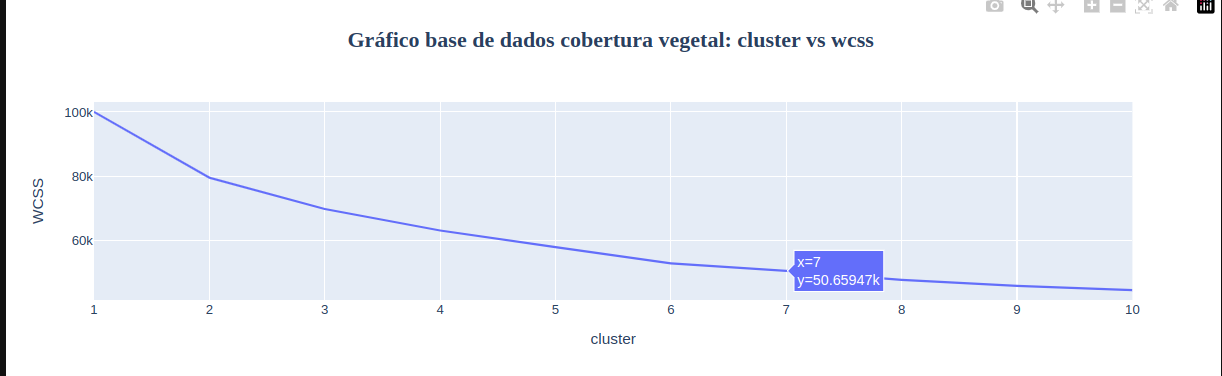

### Usar o PCA para reduzirmos a dimensionalidade dos dados, pois são mais de 2 variáveis para plotar no gráfico 2D

Qual sua conclusão a partir do gráfico?

Vamos visualizar os dados junto com os rótulos atribuídos. Para isso, precisamos utilizar a técnica PCA.

Instancie um objeto PCA com `n_components=2`, e transforme `X` para seu PCA correspondente.


Principal Component Analysis (PCA) is a dimension reduction method that is frequently used in exploratory data analysis and machine learning. This means that PCA can be leveraged to reduce the number of variables (dimensions) in a dataset without losing too much information.

https://www.codecademy.com/article/principal-component-analysis-intro

Redução da dimensionalidade => PCA (Principal Component Analysis)

In [129]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


In [130]:
pca.get_params()

{'copy': True,
 'iterated_power': 'auto',
 'n_components': 2,
 'n_oversamples': 10,
 'power_iteration_normalizer': 'auto',
 'random_state': None,
 'svd_solver': 'auto',
 'tol': 0.0,
 'whiten': False}

In [131]:
X_pca

array([[-2.12266429,  0.48483208],
       [-0.69647904,  0.04200401],
       [-1.00948182,  0.49892783],
       ...,
       [-2.3539508 ,  0.41371276],
       [-0.53816033, -1.14993512],
       [-1.59515054,  0.17062344]])

In [132]:
# reduzimos para 2 a dimensionalidade dos dados, lembrando que a base pura dos dados havia 11 colunas
# porém fica difícil fazer a visualização dos dados

In [133]:
X_pca.shape

(10000, 2)

In [134]:
print(f'São {X_pca.shape[0]} registros e {X_pca.shape[1]} colunas')

São 10000 registros e 2 colunas


Agora utilize `X_pca` para plotar os dados, usando `labels` para definir a cor dos pontos. Desta vez, utilize `labels.astype(str)` para que a biblioteca considere que os rótulos são categóricos, e não numéricos.

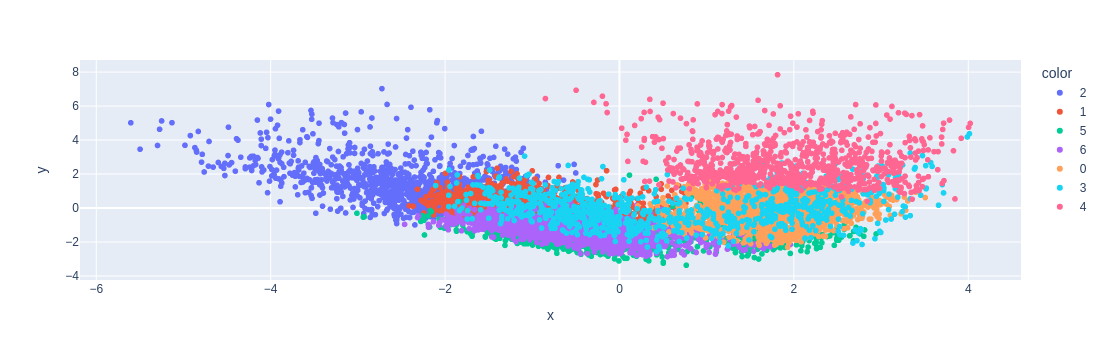

In [135]:
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=labels.astype(str))
fig.show()

In [136]:
# dados bem agrupados

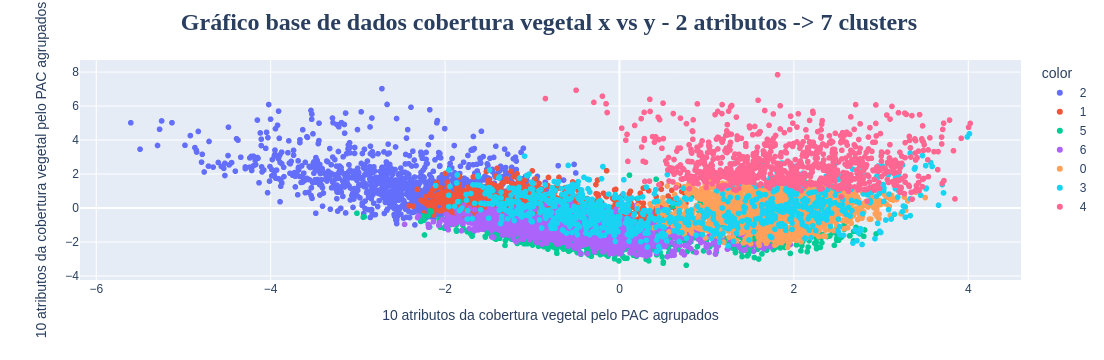

In [137]:
# x base idade e base salário
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=labels.astype(str))

# Atualiza o layout para renomear os rótulos dos eixos X e Y
fig.update_layout(
    # Defina o título aqui, no gráfico que será exibido
    title_text='<b>Gráfico base de dados cobertura vegetal x vs y - 2 atributos -> 7 clusters </b>',
    xaxis_title_text='10 atributos da cobertura vegetal pelo PAC agrupados',  
    yaxis_title_text='10 atributos da cobertura vegetal pelo PAC agrupados',
    # padrão o título
    title_font_size=24,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)
fig.show()
fig.write_html("figuras/18-8_exercicio_agrupados_grafico2.html")

In [138]:
y

0       Lodgepole Pine
1       Lodgepole Pine
2       Ponderosa Pine
3       Lodgepole Pine
4       Ponderosa Pine
             ...      
9995    Lodgepole Pine
9996    Lodgepole Pine
9997        Spruce/Fir
9998    Lodgepole Pine
9999    Lodgepole Pine
Name: Cover_Type, Length: 10000, dtype: object

### Para comparar, refaça o mesmo gráfico, mas agora utilize `y` (ou seja, os rótulos originais) para definir a cor dos pontos.

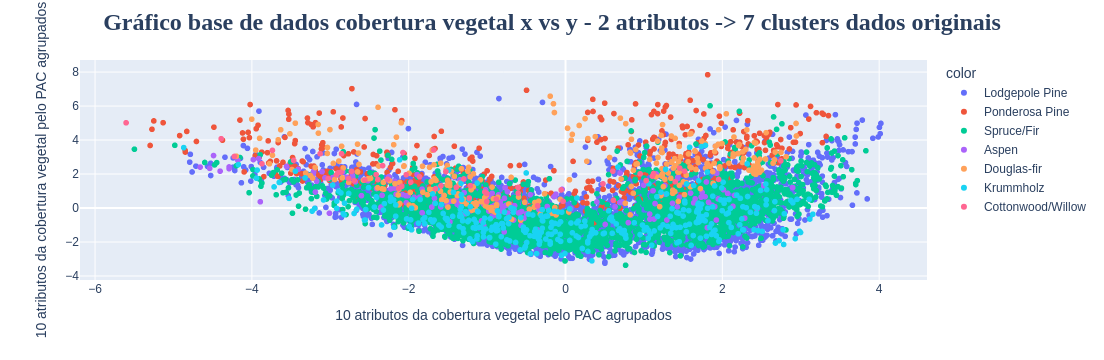

In [139]:
# x base idade e base salário
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=y)

# Atualiza o layout para renomear os rótulos dos eixos X e Y
fig.update_layout(
    # Defina o título aqui, no gráfico que será exibido
    title_text='<b>Gráfico base de dados cobertura vegetal x vs y - 2 atributos -> 7 clusters dados originais</b>',
    xaxis_title_text='10 atributos da cobertura vegetal pelo PAC agrupados',  
    yaxis_title_text='10 atributos da cobertura vegetal pelo PAC agrupados',
    # padrão o título
    title_font_size=24,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)
fig.show()
fig.write_html("figuras/18-8_exercicio_agrupados_grafico3.html")

Observe que a comparação deixa evidente que o agrupamento baseado <b style="color:red; font-size:16px; font-weight:bold;"> apenas nos atributos resulta em grupos bem diferentes daqueles discriminados pelas espécies das árvores</b>.



### Bônus: você pode comparar as classes originais com os rótulos gerados pelo algoritmo utilizando a função `pd.crosstab`:

In [140]:
pd.crosstab(labels, y)

Cover_Type,Aspen,Cottonwood/Willow,Douglas-fir,Krummholz,Lodgepole Pine,Ponderosa Pine,Spruce/Fir
row_0,,,,,,,
0,25,1,16,85,957,30,1012
1,69,20,80,30,1394,164,732
2,43,24,61,50,479,172,357
3,11,1,2,91,416,18,430
4,8,9,119,8,354,196,175
5,5,0,0,3,613,0,250
6,2,0,0,95,634,1,758


Isso indica que nenhum rótulo é característico de apenas uma classe, e vice-versa, o que confirma a visualização do gráfico.

#### Os nomes das Colunas são as classes ou as categorias, já as colunas em si são os diferentes tipos de coberturas vegetais. E  no geral os dados do meio de cada linha são as contagens de ocorrêncas para cada combinação de linhas e colunas

linhas row_0 representam as categorias, ou seja:


Aspen é a categoria com base nos dados, e row 0 indica o primeiro cluster, 1, 2, 3, 4, 5 e 6 cluster.


Como Krummholz classe 39 amostras dessa cobertura Krummholz foram agrupadas no cluster 0.


Como Spruce/Fir classe teve 356 amostras dessa cobertura agrupadas no cluster 0.


- o cluster 0 pega mais os dados do Lodgepole e do Spruce/Fir

- o cluster 1 também pega mais os dados do Lodgepole e do Spruce/Fir

- não há realmente um cluster com distribuição muito balanceada, o que chega mais próximo é o cluster número 5.

  _o que pode significar uma transição entre vários tipos de vegetação ou um grupo onde o algoritmo não conseguiu separar muito bem._ (a  respeito do cluster onde há uma distribuição balanceada)

- o cluster 1 tem o maior número de quantidade lodgepole pine, mais de 1000 dados. Além dos mais de 820 no spruce/fir
  
  _as vezes pode ser um cluster ruído para obter tantos dados agrupados em uma única variável (ou seja, que agrupou muitas amostras diferentes em um local, ou uma região onde essas classes coexistem)._

## Isso indica que nenhum rótulo é característico de apenas uma classe, e vice-versa, o que confirma a visualização do gráfico.